# Multiple Linear Regression 

## 아래처럼, 여러개의 features 를 기반으로, 수익을 예측하려 한다.

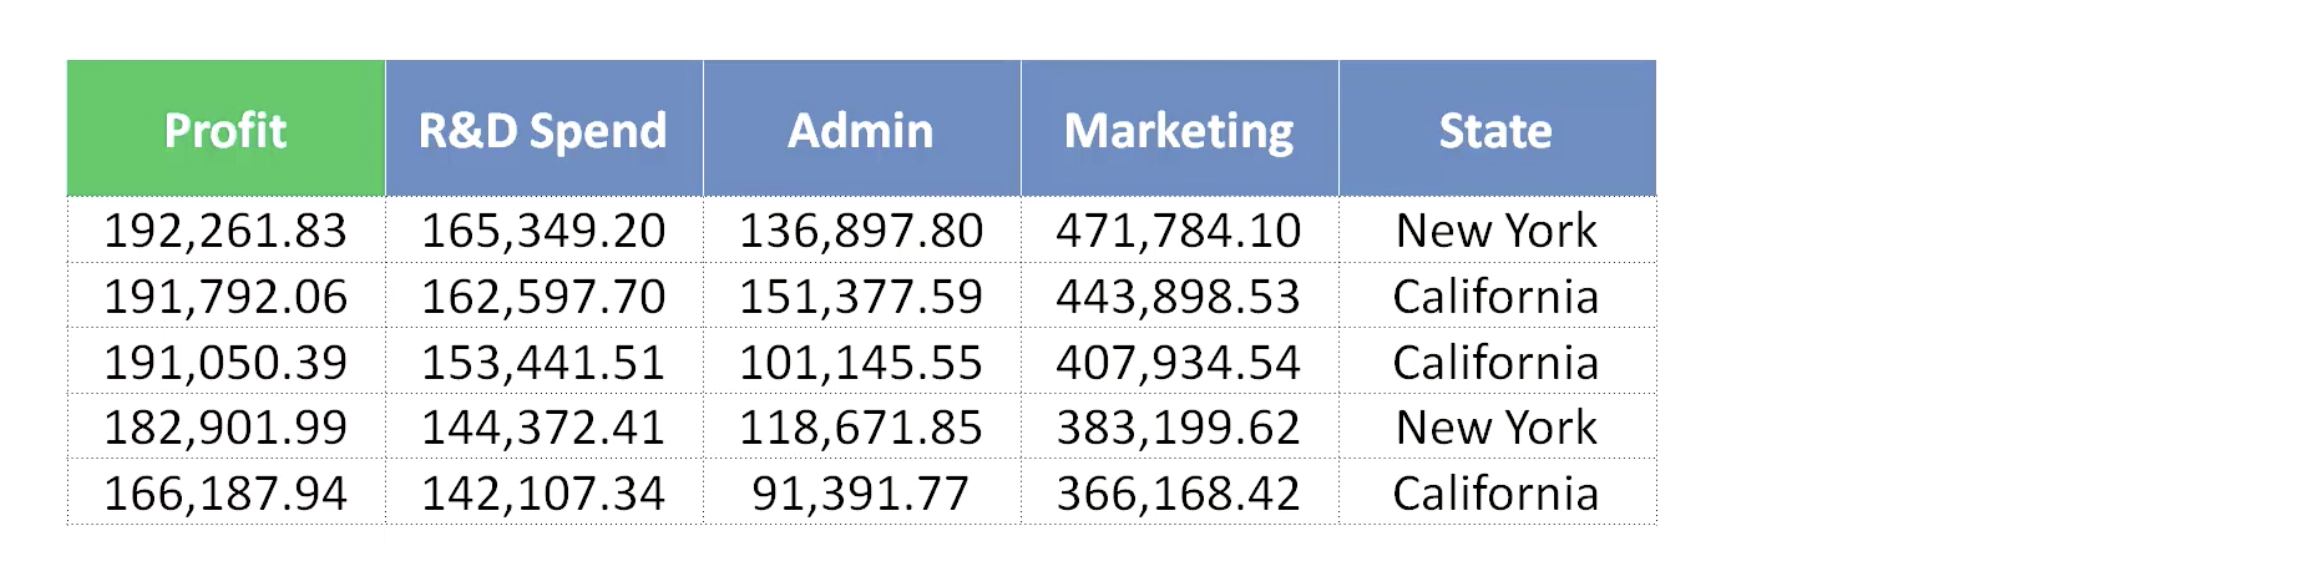

### 위와 같이, 여러개의 변수들을 통해, 수익과의 관계를 분석하고, 

### 이를 통해, 새로운 데이터가 들어왔을 때, 수익이 어떻게 될 지를 예측하고자 한다.

---

### 아래는 하나의 변수일때와, 여러개의 변수가 있을때의 leaner regression 을 나타낸다.

2차원에서는 선 이지만, 3차원에서는 평면이 된다.

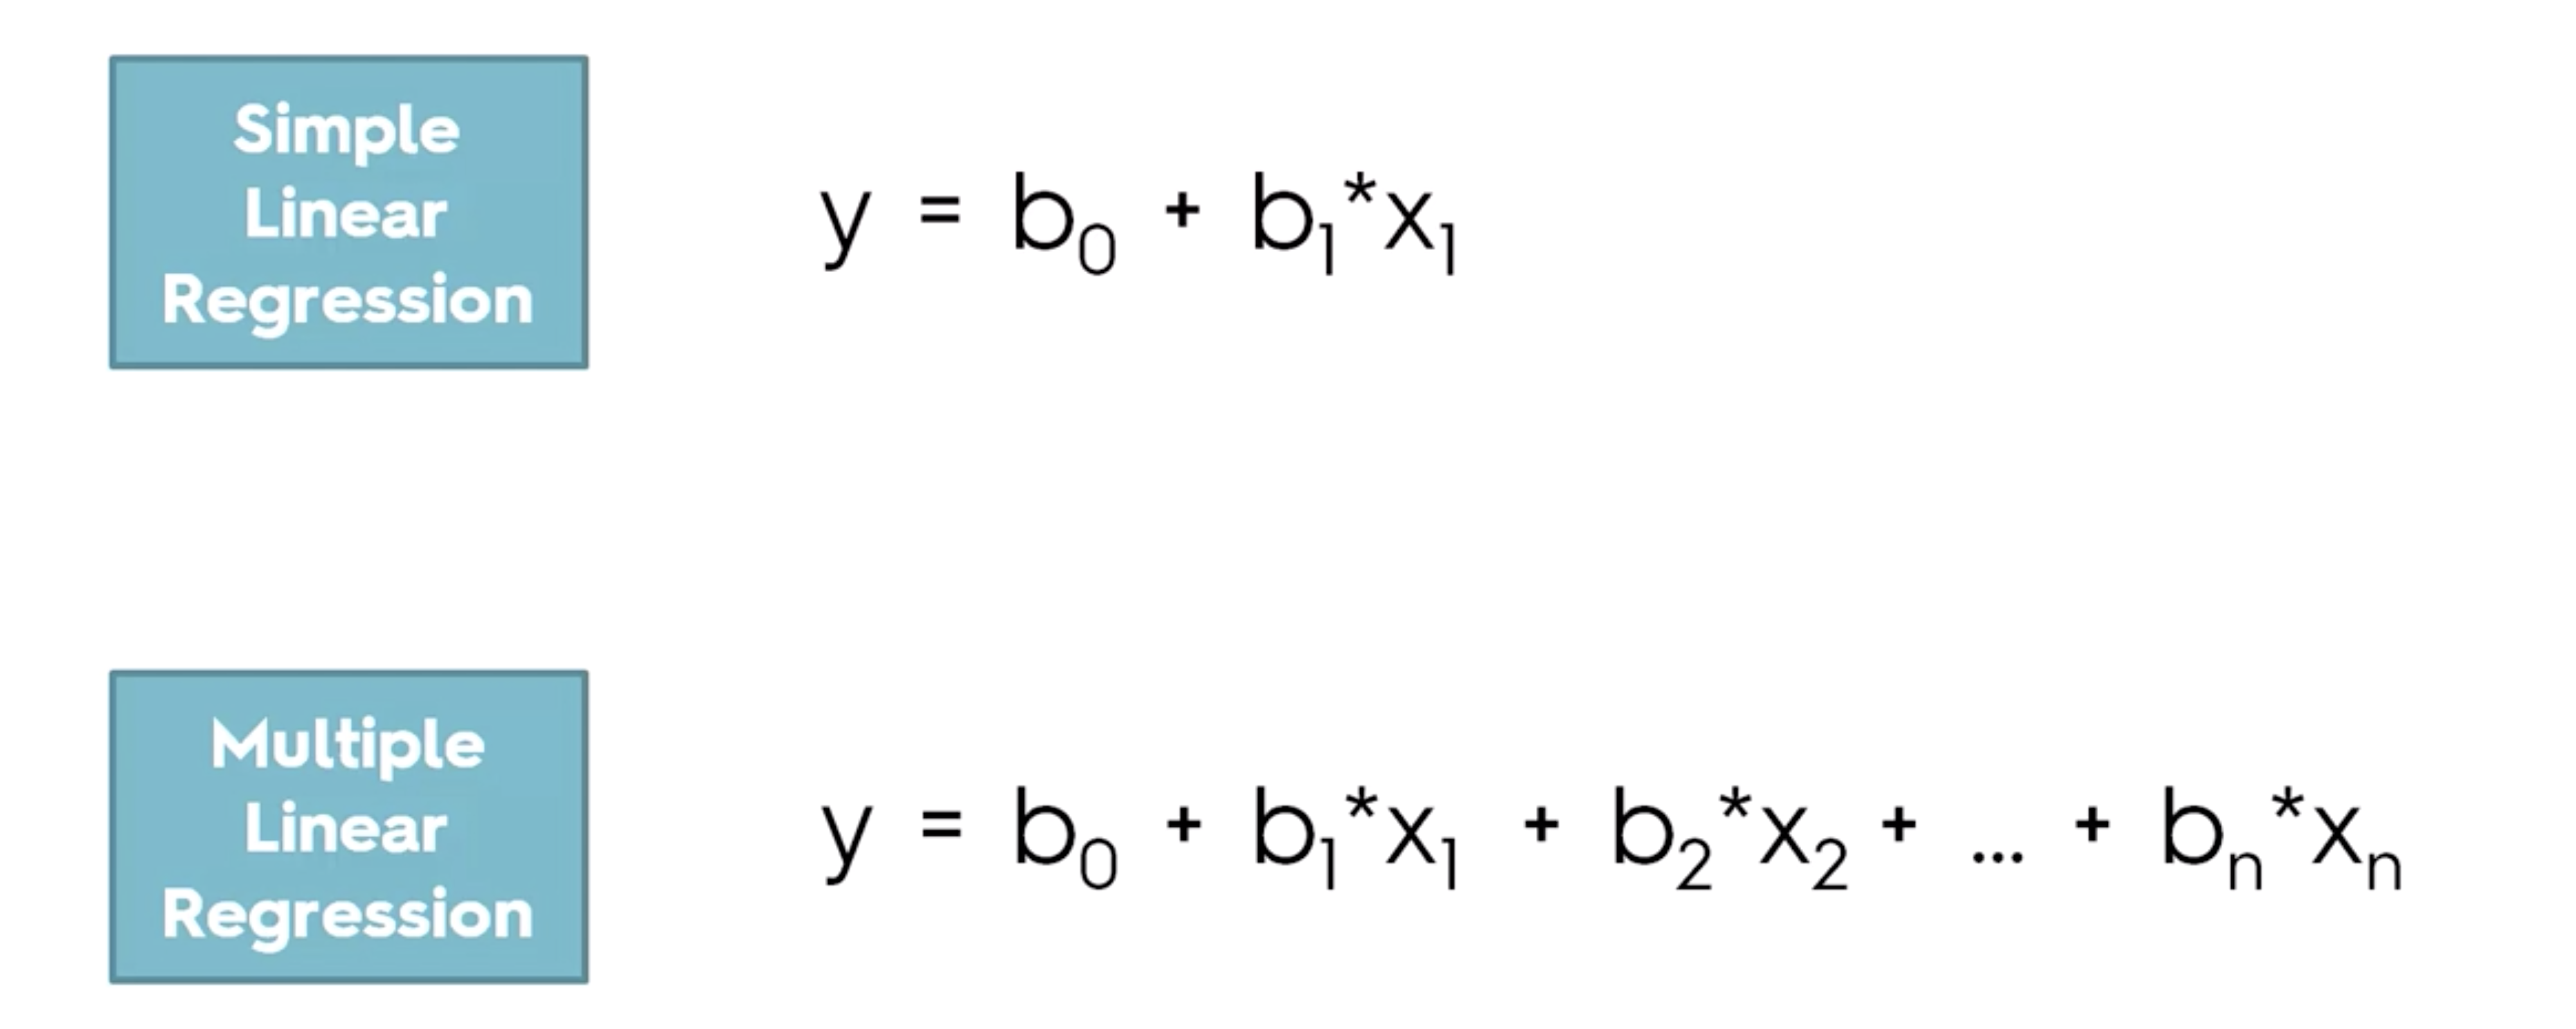

## 이제, 오차가 가장 적을때의 b 값들을 찾아보자.

In [1]:
# Profit(수익)을 예측하려 한다.  
# Profit : 종속 변수(Dependent Variable)
# 나머지 : 독립 변수(Independent Variable)

## 1. 먼저 식을 세운다. 이때 숫자가 아닌값은 어떻게 처리해야 할까?

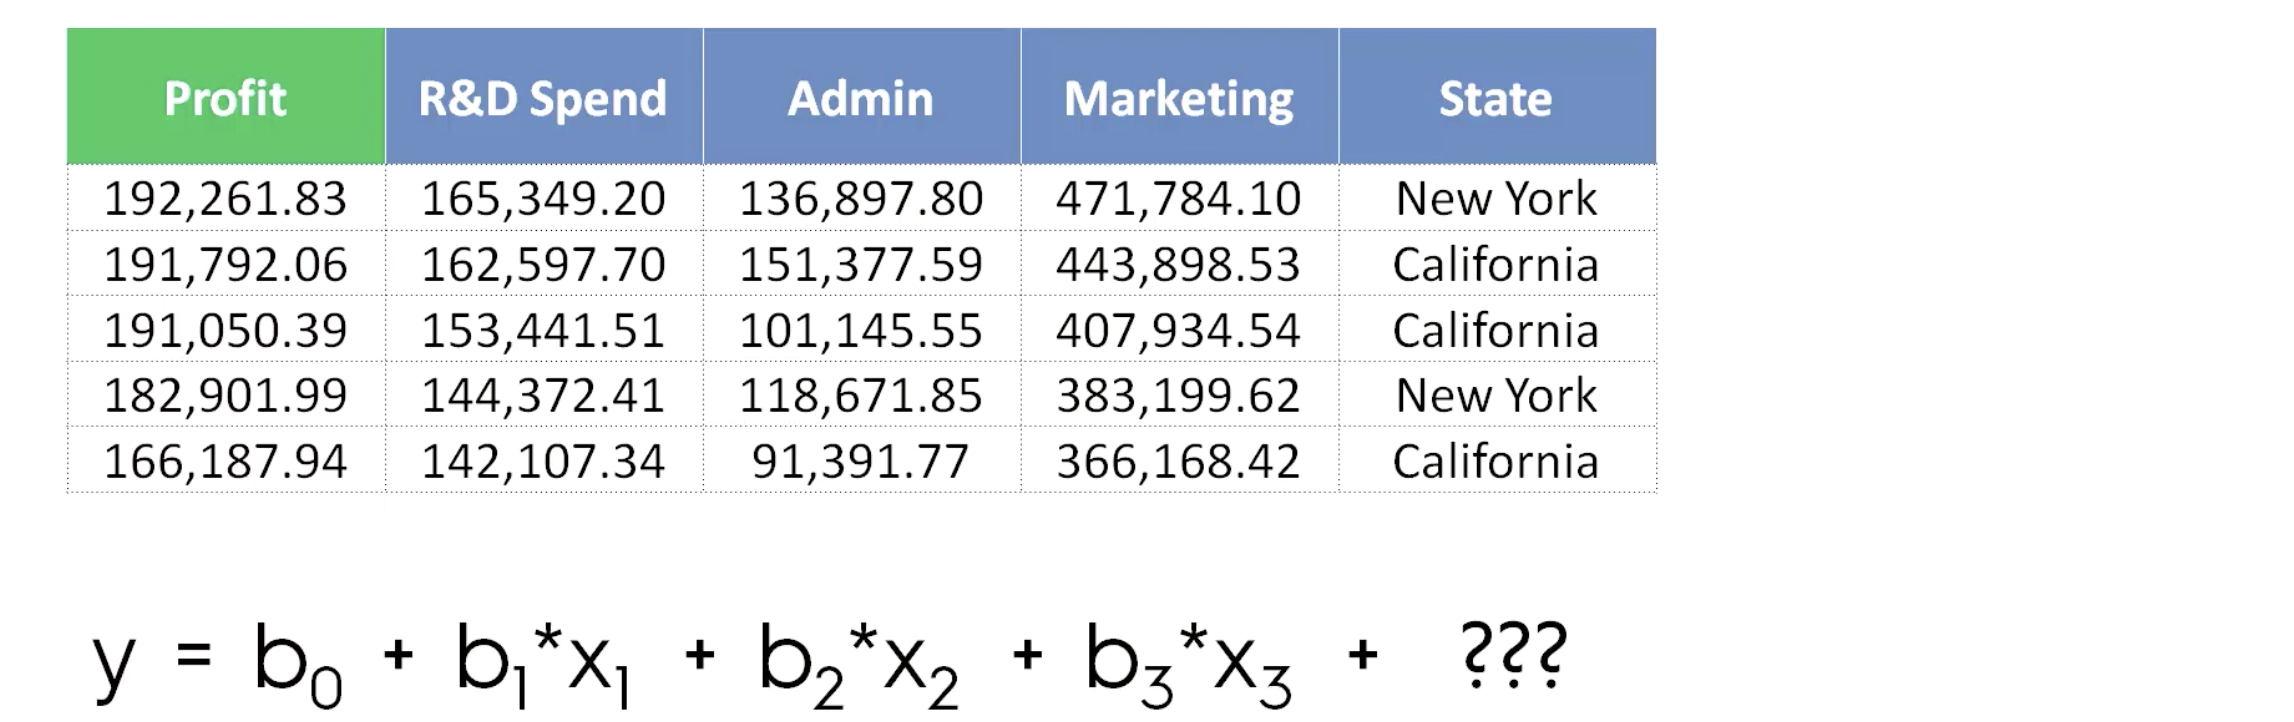

## [목표]
- 투자한 회사들이 어디에 투자를 하고, 어디에 위치했는 지에 따른 수익 예측 모델 만들기
- 신규 투자를 할 때, 의사결정 참고자료로 사용함

# lib와 데이터 로딩

In [40]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### `50_Startups.csv` 데이터를 읽으세요.

- 각각의 피쳐를 분석하여, 어떤 신생 회사의 데이터가 있으면, 그 회사가 얼마의 수익을 낼 지 예측합니다. (투자를 해야 할지 말아야 할지)
- 미국 투자 회사 정보, 투자한 회사의 수익 데이터

In [41]:
df = pd.read_csv('datas_ml/50_Startups.csv')
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [42]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     str    
 4   Profit           50 non-null     float64
dtypes: float64(4), str(1)
memory usage: 2.1 KB


In [44]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [45]:
df.describe(include='str')

,State
count,50
unique,3
top,New York
freq,17


In [46]:
df['State'].value_counts()

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

# X, y 데이터 분리

In [47]:
y = df['Profit']

In [48]:
# 행은 전부 다, 칼럼은 State까지
X = df.loc[:, 'R&D Spend':'State'] 
X.head()

,R&D Spend,Administration,Marketing Spend,State
0,165349.20,136897.80,471784.10,New York
1,162597.70,151377.59,443898.53,California
2,153441.51,101145.55,407934.54,Florida
3,144372.41,118671.85,383199.62,New York
4,142107.34,91391.77,366168.42,Florida


# 데이터 전처리

In [49]:
X['State'].nunique()

3

In [50]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [51]:
# remainder='passthrough' 나머지는 통과시켜라는 뜻
ct = ColumnTransformer([('encoder', OneHotEncoder(), [3])], remainder='passthrough')

In [52]:
# onehotencoding 수행
ct.fit_transform(X)

array([[0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 1.6534920e+05,
        1.3689780e+05, 4.7178410e+05],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 1.6259770e+05,
        1.5137759e+05, 4.4389853e+05],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 1.5344151e+05,
        1.0114555e+05, 4.0793454e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 1.4437241e+05,
        1.1867185e+05, 3.8319962e+05],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 1.4210734e+05,
        9.1391770e+04, 3.6616842e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 1.3187690e+05,
        9.9814710e+04, 3.6286136e+05],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 1.3461546e+05,
        1.4719887e+05, 1.2771682e+05],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 1.3029813e+05,
        1.4553006e+05, 3.2387668e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 1.2054252e+05,
        1.4871895e+05, 3.1161329e+05],
       [1.0000000e+00, 0.0000000e+00,

In [20]:
X[:5]

,R&D Spend,Administration,Marketing Spend,State
0,165349.20,136897.80,471784.10,New York
1,162597.70,151377.59,443898.53,California
2,153441.51,101145.55,407934.54,Florida
3,144372.41,118671.85,383199.62,New York
4,142107.34,91391.77,366168.42,Florida


In [53]:
# 문자열을 숫자로 변경 저장
X = ct.fit_transform(X)

In [54]:
X[:5]

array([[0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 1.6534920e+05,
        1.3689780e+05, 4.7178410e+05],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 1.6259770e+05,
        1.5137759e+05, 4.4389853e+05],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 1.5344151e+05,
        1.0114555e+05, 4.0793454e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 1.4437241e+05,
        1.1867185e+05, 3.8319962e+05],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 1.4210734e+05,
        9.1391770e+04, 3.6616842e+05]])

# 학습용과 테스트용으로 나눔
train_test_split(x, y, test_size=0.2, random_state=7)

In [55]:
from sklearn.model_selection import train_test_split

In [56]:
# 학습 8:테스트 2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

# 모델 학습

In [57]:
from sklearn.linear_model import LinearRegression

In [58]:
# 객체 생성
lr_model = LinearRegression()

In [59]:
# 데이터 학습
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ -431.77,-1556.82, 1988.59, 0.81, -0.03, 0.03]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.88e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[814561.11,229228.19,147024.27, 3.74, 3.27, 0. ]"


In [60]:
# 회귀선의 기울기
lr_model.coef_

array([-4.31767824e+02, -1.55681873e+03,  1.98858655e+03,  8.08286664e-01,
       -2.61729246e-02,  3.07501226e-02])

In [61]:
# 회귀선의 편차
lr_model.intercept_

np.float64(48803.93258842715)

# 모델 성능 평가

In [30]:
# 테스트
y_pred = lr_model.predict(X_test)

In [31]:
# MSE
((y_test - y_pred)**2).mean()

np.float64(100911162.80593786)

In [32]:
# 오차 결과 : RMSE
np.sqrt(((y_test - y_pred)**2).mean())

np.float64(10045.454833203814)

In [62]:
# 함수식
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

In [64]:
# 실제값, 예측값
print("MAE: ", mean_absolute_error(y_test, y_pred))
print("MSE: ", mean_squared_error(y_test, y_pred))
print("RMSE: ", root_mean_squared_error(y_test, y_pred))
print("r2-score: ",r2_score(y_test, y_pred))

MAE:  7917.874510655163
MSE:  100911162.80593786
RMSE:  10045.454833203814
r2-score:  0.8998123419674292


## 실제값과 예측값 시각화

In [33]:
df_test = y_test.to_frame()

In [34]:
df_test

,Profit
13,134307.35
15,129917.04
22,110352.25
42,71498.49
30,99937.59
27,105008.31
1,191792.06
20,118474.03
10,146121.95
36,90708.19


In [35]:
df_test['y_pred'] = y_pred

In [36]:
df_test

,Profit,y_pred
13,134307.35,126951.562112
15,129917.04,148200.835666
22,110352.25,113169.450696
42,71498.49,69514.301556
30,99937.59,97132.051584
27,105008.31,116589.986827
1,191792.06,189485.657238
20,118474.03,116210.871695
10,146121.95,133774.253314
36,90708.19,73274.890585


In [37]:
# 인덱스 리셋
df_test = df_test.reset_index(drop=True)

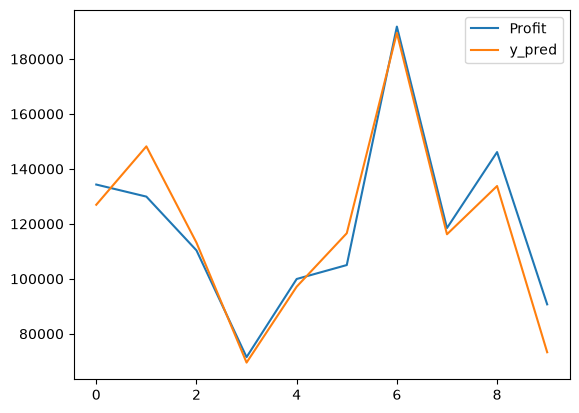

In [38]:
# 실제값과 예측 오차 시각화
df_test.plot()
plt.show()

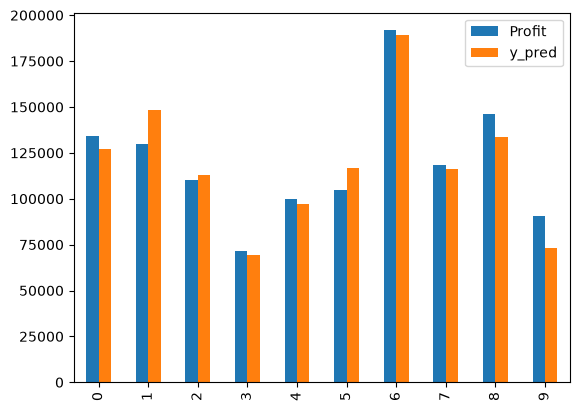

In [39]:
# 실제값과 예측 오차 시각화
df_test.plot(kind='bar')
plt.show()

# 일반화 테스트
- 실제 값을 넣어보기

In [49]:
# 저희회사는
# 운영비 15만달라, 마테팅비 40만달라, 연구개발비는 13만달러 쓰고 있습니다. 회사 위치는 플로리다에 있습니다.

In [65]:
real_data = [[0, 1, 0, 130000, 150000, 400000]]
# R&D Spend Administration Marketing Spend State
X_real = np.array(real_data)

In [66]:
X_real.shape

(1, 6)

In [67]:
y_real_pred = lr_model.predict(X_real)

In [68]:
y_real_pred

array([160698.49053133])

#### 다른 방법

In [78]:
columns = ["R&D Spend", "Administration", "Marketing Spend", "State"]
data = np.array([130000, 150000, 40000, "Florida"])
data = data.reshape(1, -1)

new_data = pd.DataFrame(data=data, columns=columns)
new_data

,R&D Spend,Administration,Marketing Spend,State
0,130000,150000,40000,Florida


In [79]:
new_data = ct.transform(new_data)
lr_model.predict(new_data)


array([149628.44637863])

[실습]
- A회사는 운영비는 15만달라, 마케팅비는 40만달라, 연구개발비는 13만달라고 회사위치는 Florida에 있음
- B회사는 운영비는 11만달라, 마케팅비는 60만달라, 연구개발비는 15만달라고 회사위치는  NewYork
- 이 두 회사의 수익을 예측하세요.
- predict 함수에 한번에 넣어서, 두 회사의 결과를 한번에 확인하세요.

In [ ]:
new_data = np.array([
    [0, 1, 0, 130000, 150000, 400000],          # A회사
    [0, 0, 1, 150000, 110000, 600000]           # B회사
])

In [70]:
new_data

array([[     0,      1,      0, 130000, 150000, 400000],
       [     0,      0,      1, 150000, 110000, 600000]])

In [71]:
lr_model.predict(new_data)

array([160698.49053133, 187606.57059607])

# 모델 저장하기 
- 예측을 잘 하면 서비스화를 위해 모델 저장하기

## 모델 저장하기

In [72]:
import joblib

In [81]:
# 모델 직렬화(모델의 메모리 상태를 그대로 파일로 저장함)
import os 

os.makedirs('models', exist_ok=True)

# 모델의 메모리의 상태 값을 그대로 파일로 저장(pkl=binary file | 열 수 없음)
joblib.dump(lr_model, 'models/lr_model.pkl')

['models/lr_model.pkl']

## 저장된 모델 로딩하여 테스트

In [75]:
ai = joblib.load('models/lr_model.pkl')

In [76]:
ai.predict(new_data)

array([160698.49053133, 187606.57059607])